# PLOTs - gradient analysis recap matrix

[INFO] AP=A vol5: fewer than 15 values, skipping
[INFO] AP=A vol6: fewer than 15 values, skipping
[INFO] AP=A vol12: fewer than 15 values, skipping
[INFO] AP=A vol13: fewer than 15 values, skipping
[INFO] AP=A vol17: fewer than 15 values, skipping
[INFO] AP=A vol24: fewer than 15 values, skipping
[INFO] AP=A vol27: fewer than 15 values, skipping
[INFO] AP=A vol35: fewer than 15 values, skipping
[INFO] AP=A vol38: fewer than 15 values, skipping
[INFO] AP=A vol39: fewer than 15 values, skipping
[INFO] AP=A vol46: fewer than 15 values, skipping
[INFO] AP=A vol47: fewer than 15 values, skipping
[INFO] AP=A vol48: fewer than 15 values, skipping
[INFO] AP=A vol49: fewer than 15 values, skipping
[INFO] AP=A vol50: fewer than 15 values, skipping
[INFO] AP=A vol60: fewer than 15 values, skipping
[INFO] AP=A vol61: fewer than 15 values, skipping
[INFO] AP=A vol69: fewer than 15 values, skipping
[INFO] AP=A vol71: fewer than 15 values, skipping
[INFO] AP=A vol72: fewer than 15 values, skipping
[I

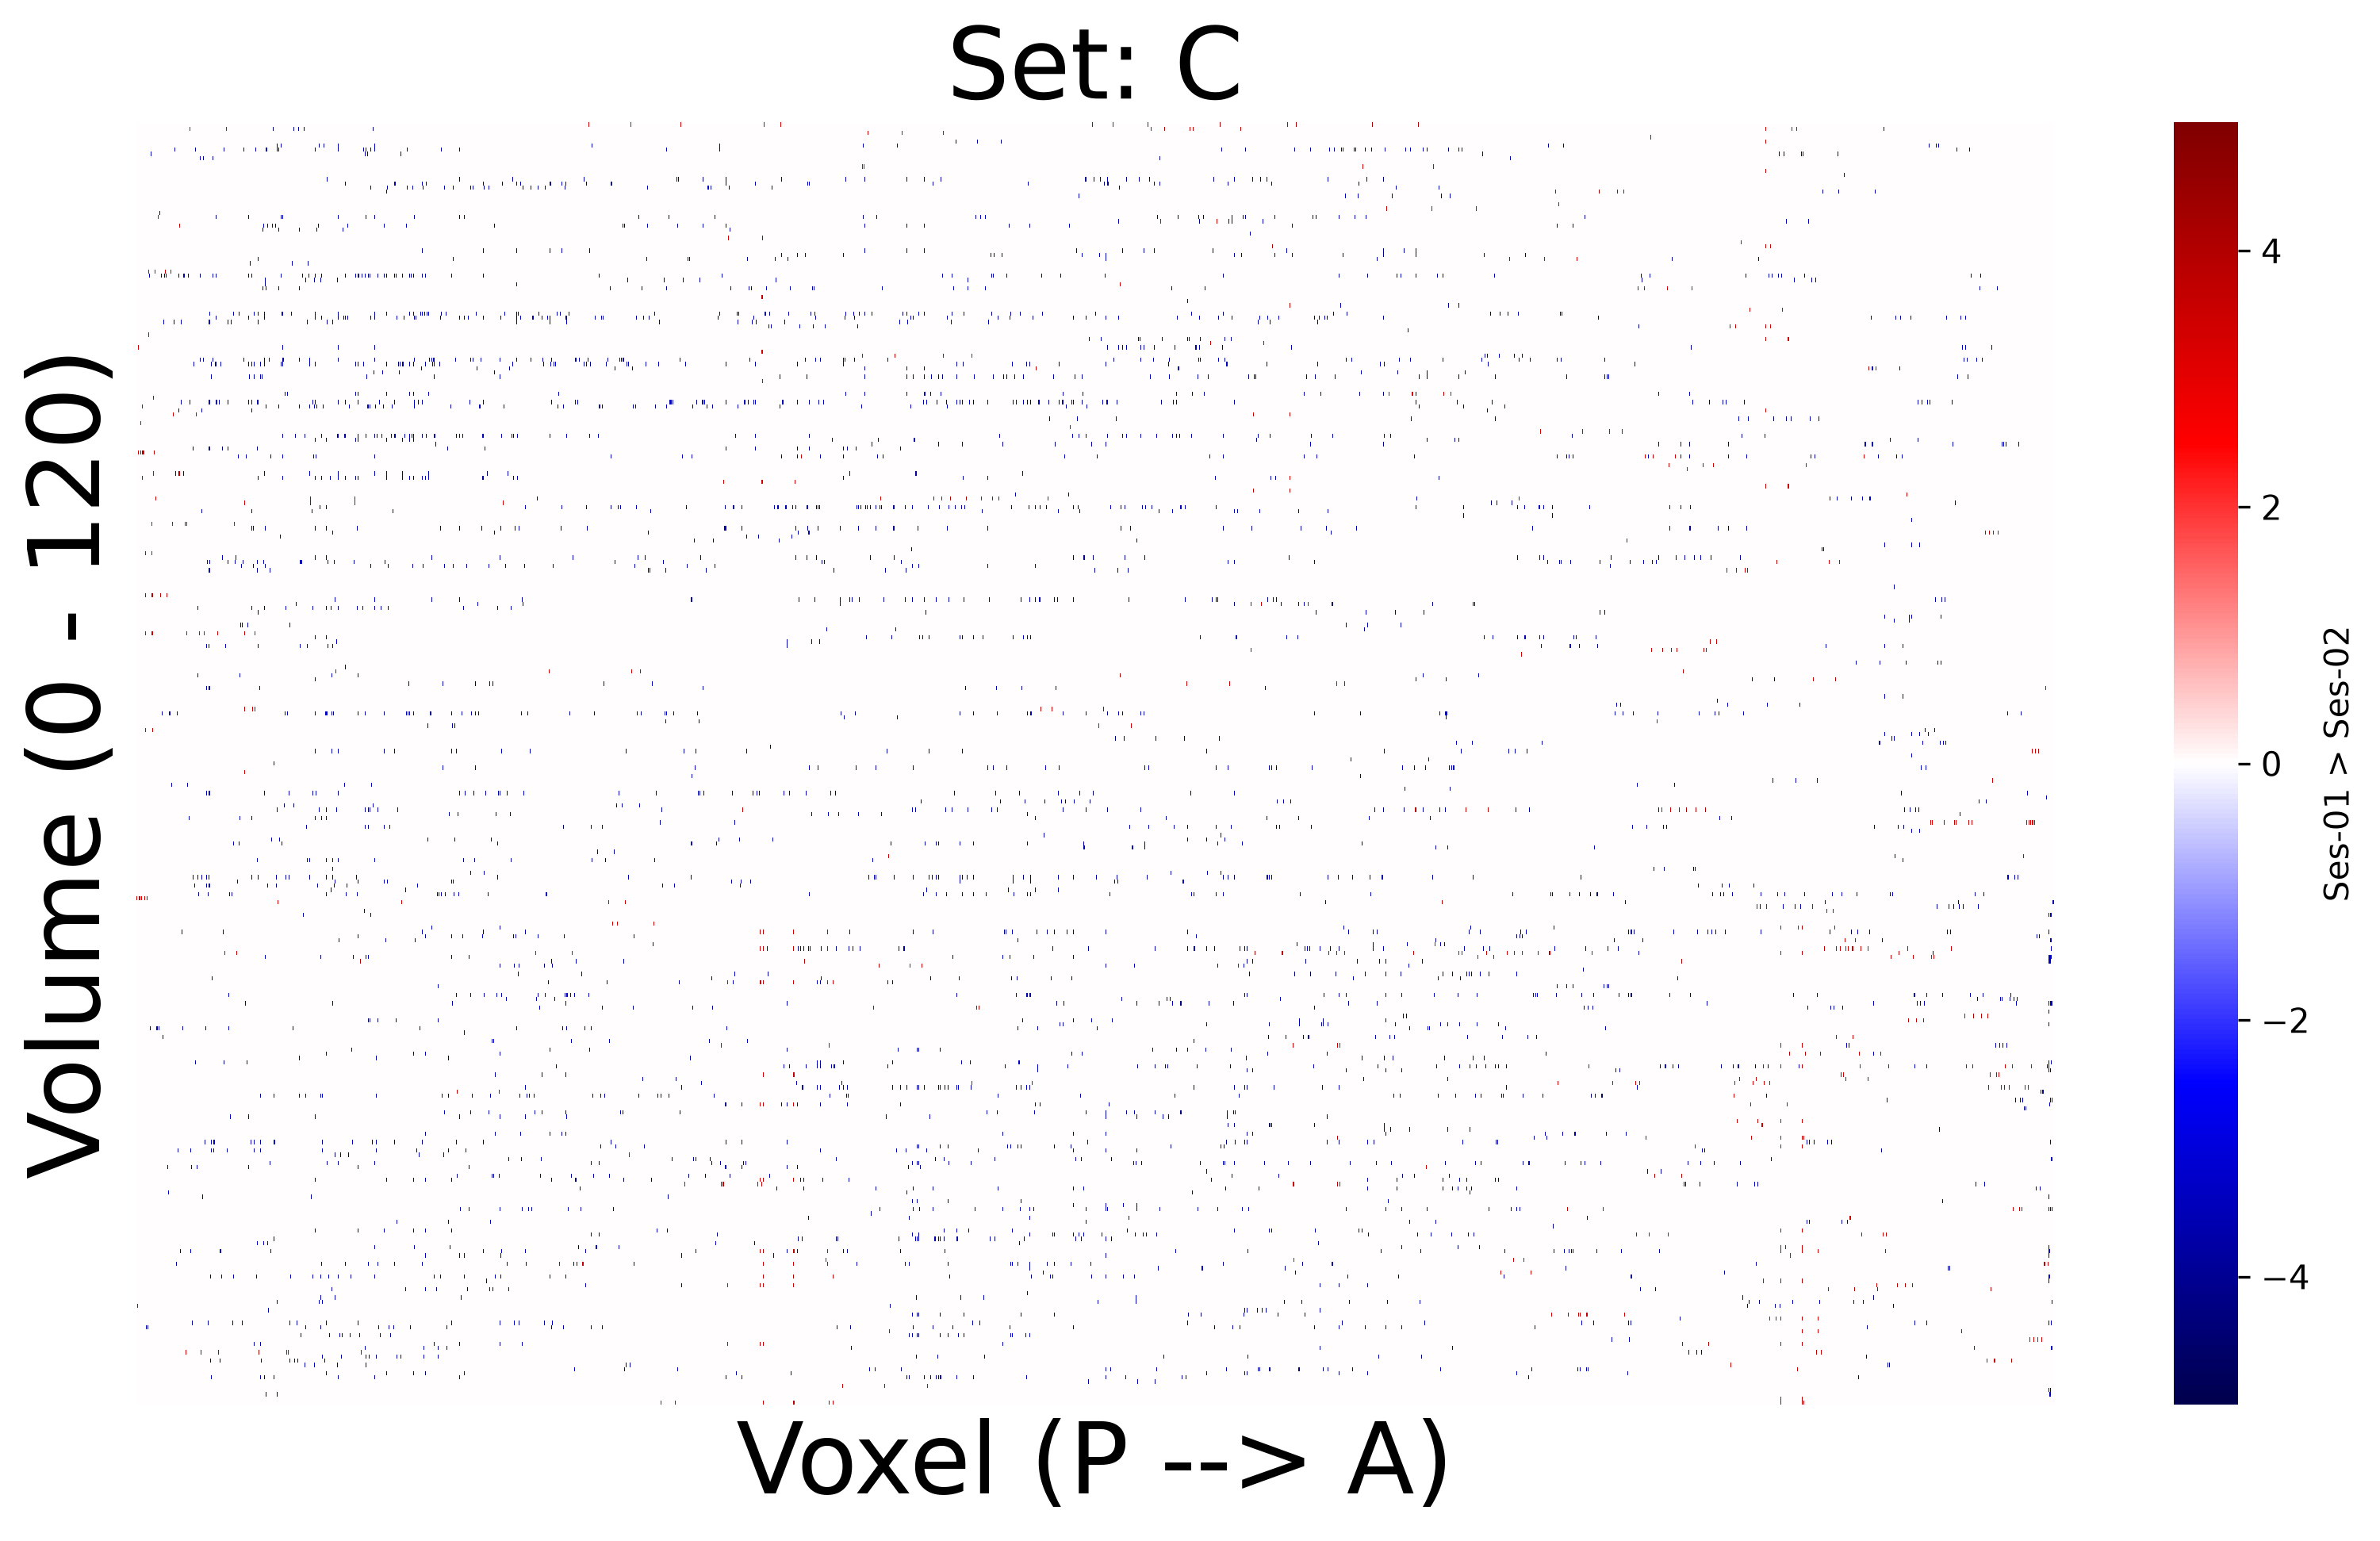

[INFO] Done


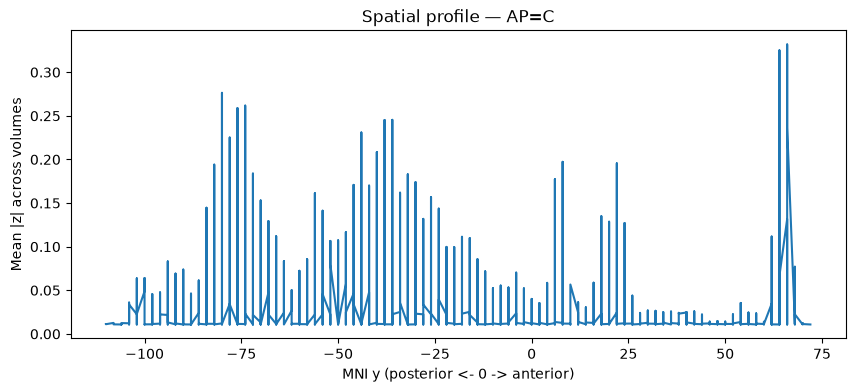

In [71]:
import os
import numpy as np
import nibabel as nib
from nibabel.affines import apply_affine
import matplotlib.pyplot as plt
import seaborn as sns

vps = [i for i in range(44) if i not in [32]]
APs = ["A", "B", "C"]
SMOOTH_FWHM_MM = "6"
ZTHRESH = 3.29
VLIM = 5  # fixed color scale: blue at -5, white/grey at 0, red at +5

home = r"/home/malberti/Unix_Folders/SWEEP2/derivatives"
out_dir = os.path.join("/home/malberti/Unix_Folders/SWEEP2", "Gradients_Stability_Analysis")
plot_dir = os.path.join(out_dir, "paired_ttest_plots")
REMOVED = 0
rows = []
row_labels = []

for AP in APs:
    ref_path = os.path.join(home, "sub-00", "ses-01", "dwi", "signal_drift", f"sub-00_ses-01_dwi_eddy_corrected_{AP}_noPA.nii")
    n_volumes = nib.load(ref_path).shape[-1]

    shape, affine = None, None

    for vol in range(n_volumes):
        zpath = os.path.join(out_dir, f"paired_ttest_zmap_{AP}_vol{vol}_smooth{SMOOTH_FWHM_MM}mm.nii.gz")
        img = nib.load(zpath)
        data = img.get_fdata()
        shape, affine = data.shape, img.affine  # same grid every volume
        data[(data > -2) & (data < 2)] = 0
        row = np.ravel(data)

        if np.count_nonzero(row) <= 0:
            print(f"[INFO] AP={AP} vol{vol}: fewer than 15 values, skipping")
            REMOVED +=1
            continue

        rows.append(row)
        row_labels.append(f"vol{vol}")

    if not rows:
        print(f"[WARN] AP={AP}: no non-empty volumes, skipping plot")
        continue

    axcodes = nib.aff2axcodes(affine)
    print(f"[INFO] AP={AP}: orientation = {axcodes}")  # confirm A/P direction before trusting the sign below

    matrix = np.vstack(rows)

sig_cols = np.any(np.abs(matrix) > ZTHRESH, axis=0)
original_voxel_indices = np.where(sig_cols)[0]

matrix = matrix[:, sig_cols]
voxel_ijk = np.array(np.unravel_index(original_voxel_indices, shape)).T
voxel_mni = apply_affine(affine, voxel_ijk)
y_coords = voxel_mni[:, 1]  # anterior-posterior axis: negative = posterior, positive = anterior (if RAS+)

sort_order = np.argsort(y_coords)  # ascending: most posterior first (left) -> most anterior last (right)
matrix = matrix[:, sort_order]
y_sorted = y_coords[sort_order]

    
fig, ax = plt.subplots(figsize=(13, 7), dpi=300)

sns.heatmap(
matrix,
cmap="seismic", center=0, vmin=-VLIM, vmax=VLIM,
cbar=True, cbar_kws={"label": "Ses-01 > Ses-02"},
linecolor='black',
xticklabels=False, yticklabels=False,
ax=ax, robust=True, annot=False,
square=False,
)

ax.set_title(f"Set: {AP}",fontsize=30)
ax.set_xlabel("Voxel (P --> A)",fontsize=30)
ax.set_ylabel("Volume (0 - 120)", fontsize=30)

plt.show()

print("[INFO] Done")


mean_abs_z = np.mean(np.abs(matrix), axis=0)
plt.figure(figsize=(10, 4))
plt.plot(y_sorted, mean_abs_z)
plt.xlabel("MNI y (posterior <- 0 -> anterior)")
plt.ylabel("Mean |z| across volumes")
plt.title(f"Spatial profile — AP={AP}")
plt.show()

# Matrix plot - RESHAPING 
-----------------------------------
The blocks below aim to reshpae the above computed matrix, the idea is to group volumes acqured by direction and bvalue. In order to improve data visualization 
1) Compute the Matrix, keep the post-> ant order and don't remove empty images, we need them to index. 
2) Create an index/dictionary or anything else usefull to sort bval and gradient. 
3) Plot everything 

matrix_ABC
│
├── rows   0–120   → A volumes 0–120
├── rows 121–241   → B volumes 0–120
└── rows 242–362   → C volumes 0–120

In [ ]:
# -> Matrix 
import os
import numpy as np
import nibabel as nib
from nibabel.affines import apply_affine
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import subprocess
import tempfile
from nilearn import image as nlimage
from concurrent.futures import ProcessPoolExecutor
import warnings
import re
import pandas as pd
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_design_matrix, plot_glass_brain
from nilearn.glm.second_level import SecondLevelModel
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

vps = [i for i in range(44) if i not in [32]]
APs = ["A", "B", "C"]
sessions = ["ses-01", "ses-02"]
home = r"/home/malberti/Unix_Folders/SWEEP2/derivatives"

vp_ABC=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 39, 40, 41, 43]
vp_BCA=[18, 19, 20, 21, 23, 24, 22, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 42]

TEMPLATE = "MNI"   # "HCPex" or "MNI"
TEMPLATE_PATHS = {
    "HCPex": r"/home/malberti/Unix_Folders/SWEEP2/Script/DEWEY_v6/Atlases/MNI_icbm_152_Template_pl-MNI152NLin2009cAsym_res-02_desc-brain_T1w.nii.gz",
    "MNI":   r"/usr/local/fsl/data/standard/MNI152_T1_2mm_brain.nii.gz",
}

TEMPLATE_PATH = TEMPLATE_PATHS[TEMPLATE]

BVAL_TOLERANCE = 50
SMOOTH_FWHM_MM = 6
ZTHRESH = 3.29
VLIM = 5  # fixed color scale: blue at -5, white/grey at 0, red at +5

QUADRANT_indx = {}  # {(AP, shell): {"FIRST_Oct": [...], ...}}

VECTOR = []
APs = ["A", "B", "C"]

home = r"/home/malberti/Unix_Folders/SWEEP2/derivatives"
out_dir = os.path.join("/home/malberti/Unix_Folders/SWEEP2", "Gradients_Stability_Analysis")
plot_dir = os.path.join(out_dir, "paired_ttest_plots")


In [ ]:
MATRICES = []

for AP in APs:
    ref_path = os.path.join(home, "sub-00", "ses-01", "dwi", "signal_drift", f"sub-00_ses-01_dwi_eddy_corrected_{AP}_noPA.nii")
    n_volumes = nib.load(ref_path).shape[-1]

    rows = []
    row_labels = []
    shape, affine = None, None

    for vol in range(n_volumes):
        zpath = os.path.join(out_dir, f"paired_ttest_zmap_{AP}_vol{vol}_smooth{SMOOTH_FWHM_MM}mm.nii.gz")
        img = nib.load(zpath)
        data = img.get_fdata()
        shape, affine = data.shape, img.affine  # same grid every volume
        row = np.ravel(data)
        rows.append(row)
        row_labels.append(f"vol{vol}")

    axcodes = nib.aff2axcodes(affine)
    print(f"[INFO] AP={AP}: orientation = {axcodes}")  # confirm A/P direction before trusting the sign below

    matrix = np.vstack(rows)

    MATRICES.append(matrix)
MATRICES = np.vstack(MATRICES)

In [ ]:
for AP in APs:
    dvs_path = f"/home/malberti/wks14/temp/FF_DWI_Drift/DWI_plit_{AP}.dvs"
    bvals = os.path.join(home, "sub-04", "ses-01", "dwi", "signal_drift", f"sub-04_ses-01_dwi_eddy_corrected_{AP}_noPA.bval")
    BVALs = np.loadtxt(bvals)

    vectors = []
    with open(dvs_path) as f:
        for line in f:
            match = re.match(r"Vector\[\d+\]\s*=\s*\(([-\d.]+),([-\d.]+),([-\d.]+)\)", line)
            if match:
                vectors.append([float(match.group(1)), float(match.group(2)), float(match.group(3))])

    vectors = np.array(vectors)
    vectors = np.vstack([[0.0, 0.0, 0.0], vectors])
    AP_marks = np.full((len(vectors), 1), AP)

    print(f"[INFO] AP={AP}: parsed {len(vectors)} | {len(BVALs)} vectors from {dvs_path}")

    VECTOR.append(np.column_stack((vectors, BVALs, AP_marks)))

index = np.tile(np.arange(121), 3).reshape(-1, 1)             # collapse the list of (n_i, 4) arrays into one (total_n, 4) array
VECTORs = np.vstack(VECTOR)              # collapse the list of (n_i, 4) arrays into one (total_n, 4) array

VECTORs = np.column_stack([VECTORs, index])  # now (total_n, 5): x, y, z, bval, index


# Get the index 
tolerance = 50
SHELLs = np.unique(np.round(BVALs / tolerance) * tolerance)
N_volumes = 0

for shell in SHELLs:
    bSHELL_Vectors = VECTORs[(VECTORs[:, 3].astype(float) > shell - tolerance) & (VECTORs[:, 3].astype(float) < shell + tolerance)]

    FIRST_Oct = bSHELL_Vectors[
        ((bSHELL_Vectors[:, 0].astype(float) > 0) & (bSHELL_Vectors[:, 1].astype(float) < 0) & (bSHELL_Vectors[:, 2].astype(float) > 0)) |
        ((bSHELL_Vectors[:, 0].astype(float) < 0) & (bSHELL_Vectors[:, 1].astype(float) > 0) & (bSHELL_Vectors[:, 2].astype(float) < 0))
    ]

    SECOND_Oct = bSHELL_Vectors[
        ((bSHELL_Vectors[:, 0].astype(float) > 0) & (bSHELL_Vectors[:, 1].astype(float) < 0) & (bSHELL_Vectors[:, 2].astype(float) < 0)) |
        ((bSHELL_Vectors[:, 0].astype(float) < 0) & (bSHELL_Vectors[:, 1].astype(float) > 0) & (bSHELL_Vectors[:, 2].astype(float) > 0))
    ]
    THIRD_Oct = bSHELL_Vectors[
        ((bSHELL_Vectors[:, 0].astype(float) > 0) & (bSHELL_Vectors[:, 1].astype(float) > 0) & (bSHELL_Vectors[:, 2].astype(float) > 0)) |
        ((bSHELL_Vectors[:, 0].astype(float) < 0) & (bSHELL_Vectors[:, 1].astype(float) < 0) & (bSHELL_Vectors[:, 2].astype(float) < 0))
    ]
    FOURTH_Oct = bSHELL_Vectors[
        ((bSHELL_Vectors[:, 0].astype(float) > 0) & (bSHELL_Vectors[:, 1].astype(float) > 0) & (bSHELL_Vectors[:, 2].astype(float) < 0)) |
        ((bSHELL_Vectors[:, 0].astype(float) < 0) & (bSHELL_Vectors[:, 1].astype(float) < 0) & (bSHELL_Vectors[:, 2].astype(float) > 0))
    ]

    QUADRANT_indx[(shell)] = {
        "FIRST_Oct": FIRST_Oct[:],
        "SECOND_Oct": SECOND_Oct[:],
        "THIRD_Oct": THIRD_Oct[:],
        "FOURTH_Oct": FOURTH_Oct[:],
    }

    N_volumes = N_volumes + len(bSHELL_Vectors)
    print(f"[INFO]  shell {shell}: FIRST={len(FIRST_Oct)} SECOND={len(SECOND_Oct)} THIRD={len(THIRD_Oct)} FOURTH={len(FOURTH_Oct)}")
    print(f"[INFO] shell {shell}: {len(bSHELL_Vectors)} volumes/indices")

print(f"[INFO] Grand total across all shells: {N_volumes}")

In [ ]:
import matplotlib.pyplot as plt

ABC_shifter = {
    "A": 0,
    "B": 120,
    "C": 241
}

for shell, quadrant in QUADRANT_indx.items():
    if shell < 50: 
        continue
    shell_MATRIX = []
    quadrant_boundaries = []  # row index where each new quadrant starts
    quadrant_labels = []
    row_count = 0

    for label, vol_index in quadrant.items():
        quadrant_boundaries.append(row_count)
        quadrant_labels.append(label)

        for item in vol_index:
            volume = int(item[5])
            bvalue = item[3]
            AP = item[4]
            volume_shifted = volume + ABC_shifter[AP]

            shell_MATRIX.append(MATRICES[volume_shifted, :])
            row_count += 1
            print(volume, volume_shifted, AP, bvalue)

    shell_MATRIX = np.vstack(shell_MATRIX)


    # --- plot ---
    fig, (ax_strip, ax) = plt.subplots(2, 1, figsize=(10, 5), dpi=300, gridspec_kw={"height_ratios": [0.003, 1]}, constrained_layout=True)

    strip = ax_strip.imshow(y_sorted[np.newaxis, :], aspect="auto", cmap="viridis")
    ax_strip.set_xticks([])
    ax_strip.set_yticks([])
    ax_strip.set_title(f"Shell {shell}", fontsize=20)
    fig.colorbar(strip, ax=ax_strip, orientation="horizontal", fraction=0.3, pad=0.4, label="MNI y (posterior <- 0 -> anterior)")

    sns.heatmap(
        shell_MATRIX,
        cmap="bwr", center=0,
        cbar_kws={"label": "value"}, linecolor="black",
        xticklabels=False, yticklabels=False,
        ax=ax,
    )

    ax.set_xlabel("Voxel, sorted posterior (left) -> anterior (right)")
    ax.set_ylabel("Volume (grouped by quadrant)")

    # mark quadrant boundaries on the heatmap
    for b, lbl in zip(quadrant_boundaries, quadrant_labels):
        ax.axhline(y=b, color="black", linewidth=1)
        ax.text(shell_MATRIX.shape[1] + 5, b, lbl, va="top", fontsize=8, color="black")

    out_path = os.path.join(plot_dir, f"zmap_matrix_shell{int(shell)}.png")
    plt.show()
    print(f"[INFO] Saved {out_path}")

[WARN] shell=0.0: no non-empty volumes, skipping plot
[INFO] shell=500.0 FIRST_Oct AP=A vol50: entirely empty, skipping
[INFO] shell=500.0 FIRST_Oct AP=B vol11: entirely empty, skipping
[INFO] shell=500.0 FIRST_Oct AP=B vol99: entirely empty, skipping
[INFO] shell=500.0 SECOND_Oct AP=A vol39: entirely empty, skipping
[INFO] shell=500.0 SECOND_Oct AP=B vol88: entirely empty, skipping
[INFO] shell=500.0 THIRD_Oct AP=A vol17: entirely empty, skipping
[INFO] shell=500.0 THIRD_Oct AP=A vol61: entirely empty, skipping
[INFO] shell=500.0 THIRD_Oct AP=A vol72: entirely empty, skipping
[INFO] shell=500.0 THIRD_Oct AP=B vol33: entirely empty, skipping
[INFO] shell=500.0 THIRD_Oct AP=B vol110: entirely empty, skipping
[INFO] shell=500.0 FOURTH_Oct AP=A vol6: entirely empty, skipping
[INFO] shell=500.0 FOURTH_Oct AP=A vol83: entirely empty, skipping
[INFO] shell=500.0 FOURTH_Oct AP=B vol55: entirely empty, skipping
[INFO] shell=500.0 FOURTH_Oct AP=B vol77: entirely empty, skipping
[INFO] shell=500

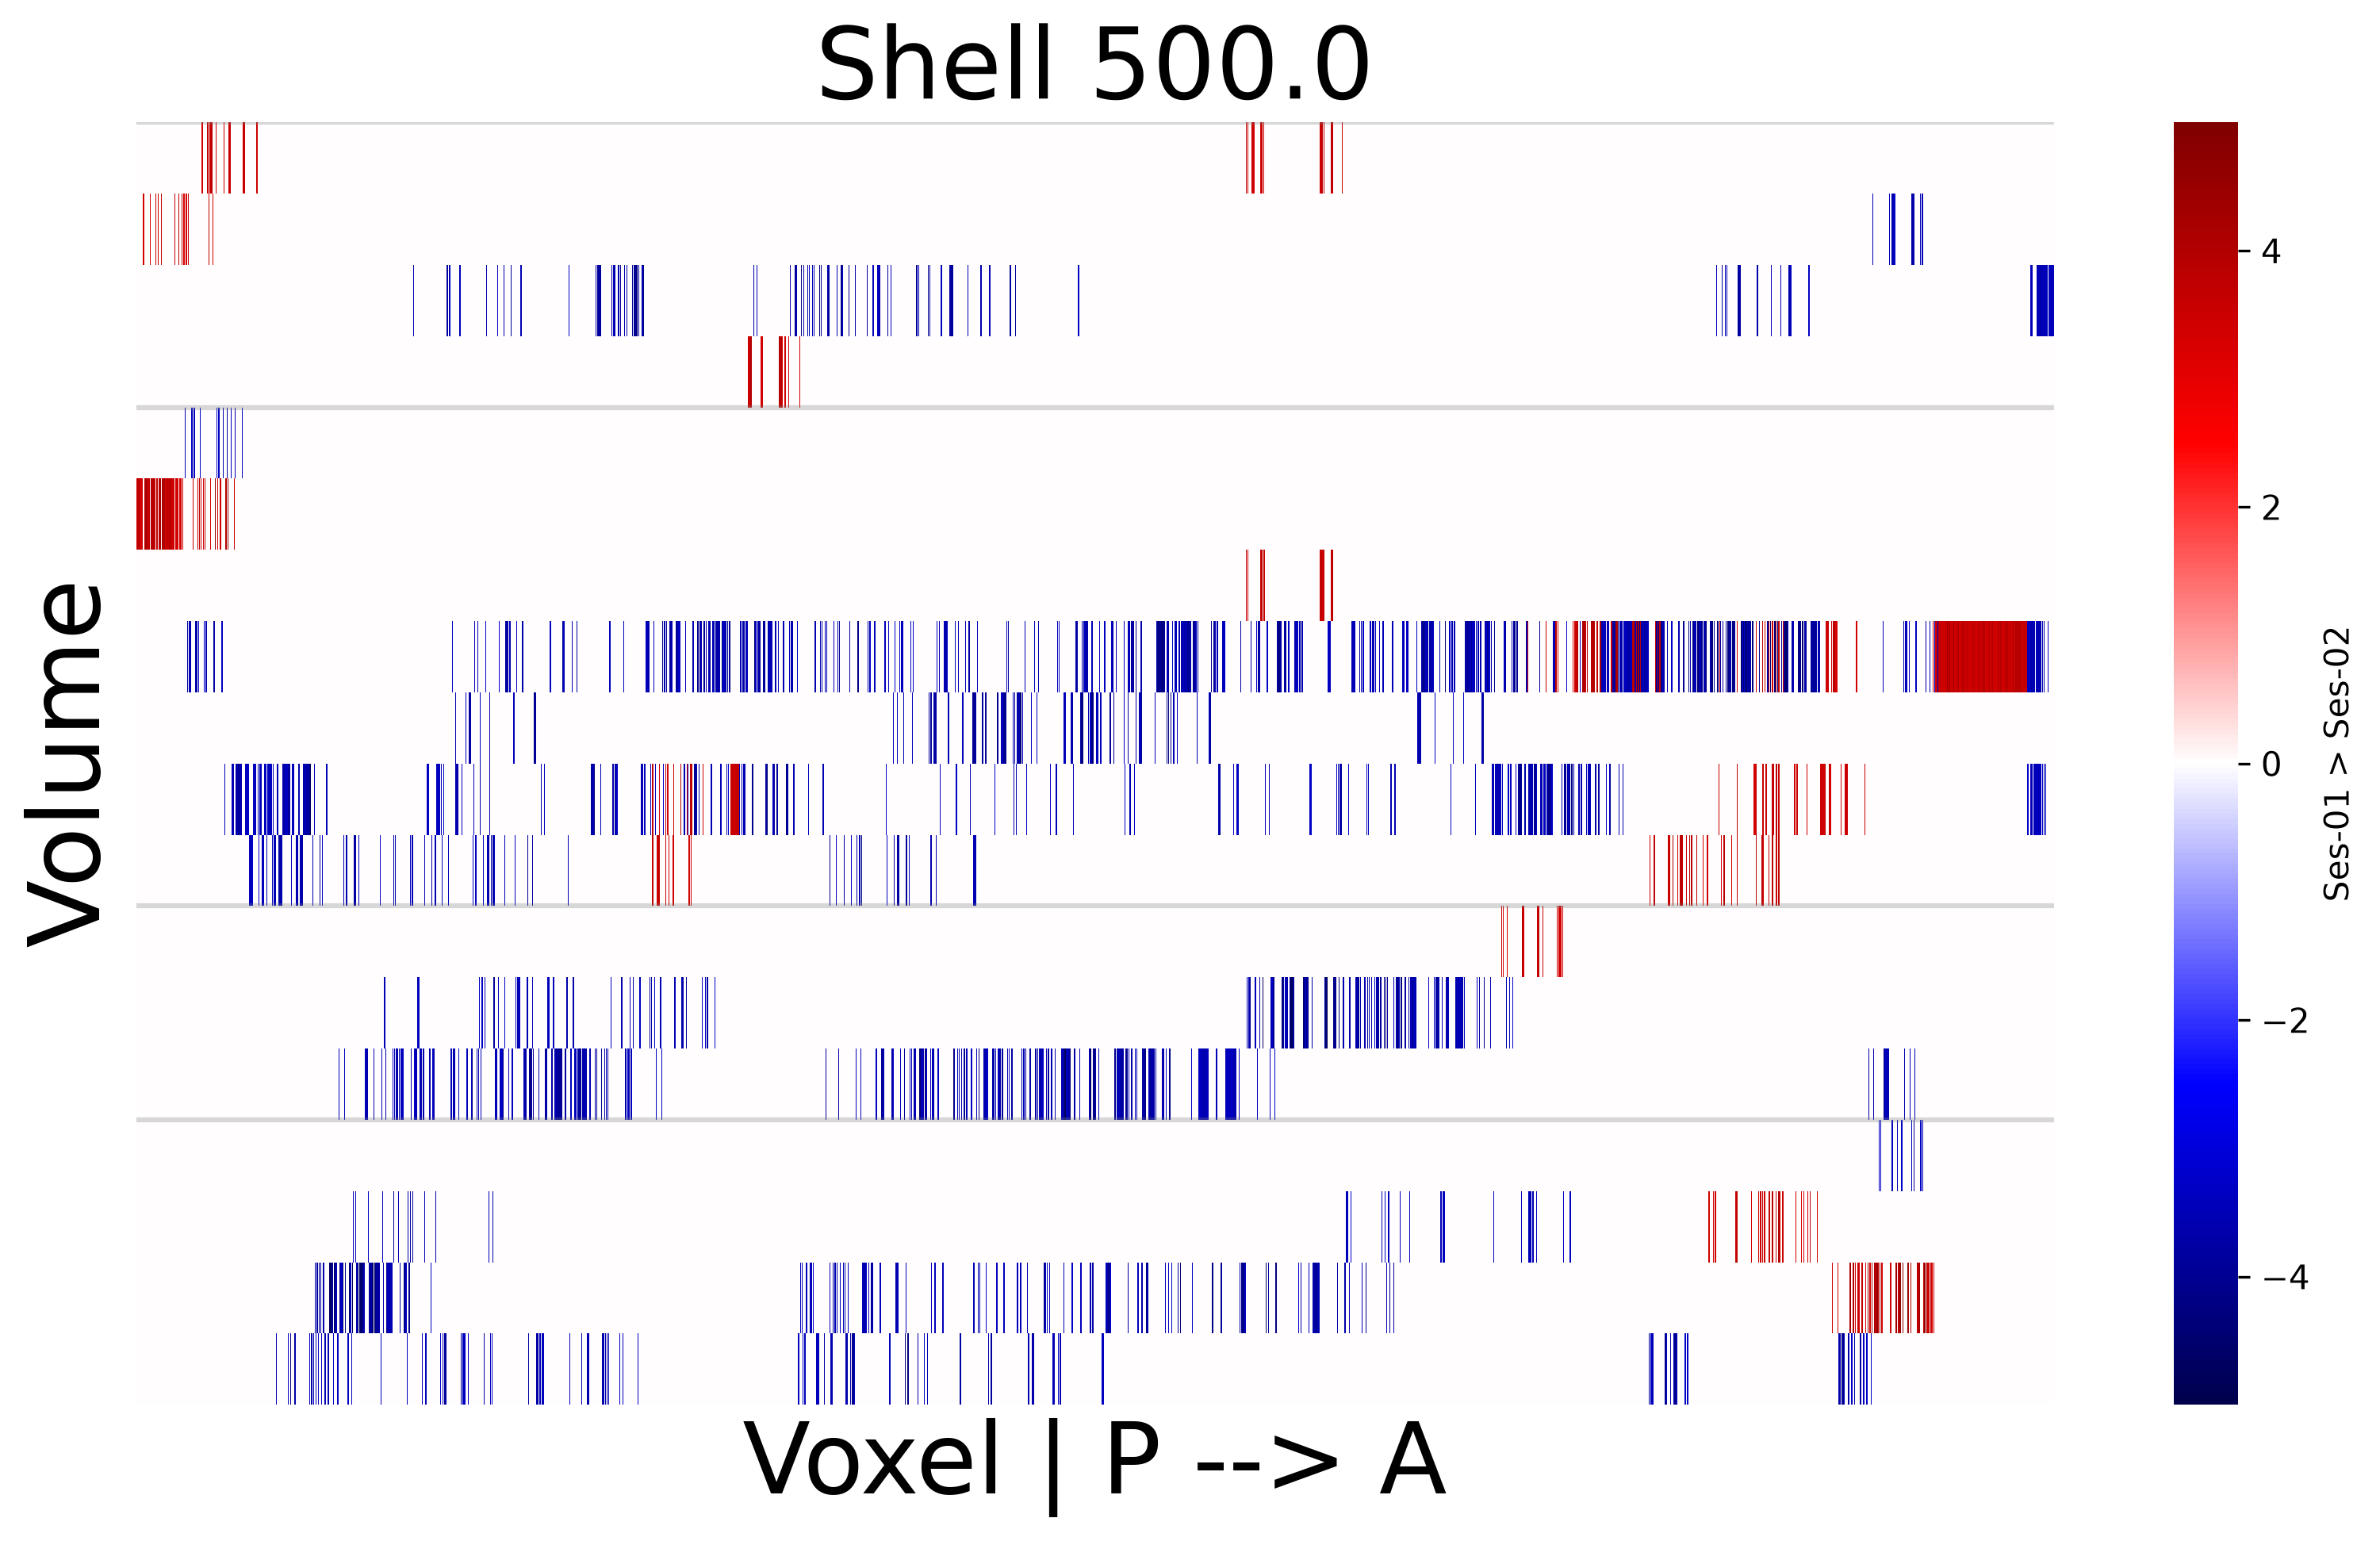

[INFO] shell=1000.0 FIRST_Oct AP=B vol16: entirely empty, skipping
[INFO] shell=1000.0 FIRST_Oct AP=B vol49: entirely empty, skipping
[INFO] shell=1000.0 FIRST_Oct AP=B vol71: entirely empty, skipping
[INFO] shell=1000.0 FIRST_Oct AP=B vol116: entirely empty, skipping
[INFO] shell=1000.0 SECOND_Oct AP=A vol24: entirely empty, skipping
[INFO] shell=1000.0 SECOND_Oct AP=A vol46: entirely empty, skipping
[INFO] shell=1000.0 SECOND_Oct AP=A vol101: entirely empty, skipping
[INFO] shell=1000.0 SECOND_Oct AP=A vol112: entirely empty, skipping
[INFO] shell=1000.0 SECOND_Oct AP=B vol38: entirely empty, skipping
[INFO] shell=1000.0 SECOND_Oct AP=B vol60: entirely empty, skipping
[INFO] shell=1000.0 THIRD_Oct AP=A vol79: entirely empty, skipping
[INFO] shell=1000.0 THIRD_Oct AP=B vol27: entirely empty, skipping
[INFO] shell=1000.0 THIRD_Oct AP=B vol105: entirely empty, skipping
[INFO] shell=1000.0 FOURTH_Oct AP=A vol13: entirely empty, skipping
[INFO] shell=1000.0 FOURTH_Oct AP=A vol35: entirely

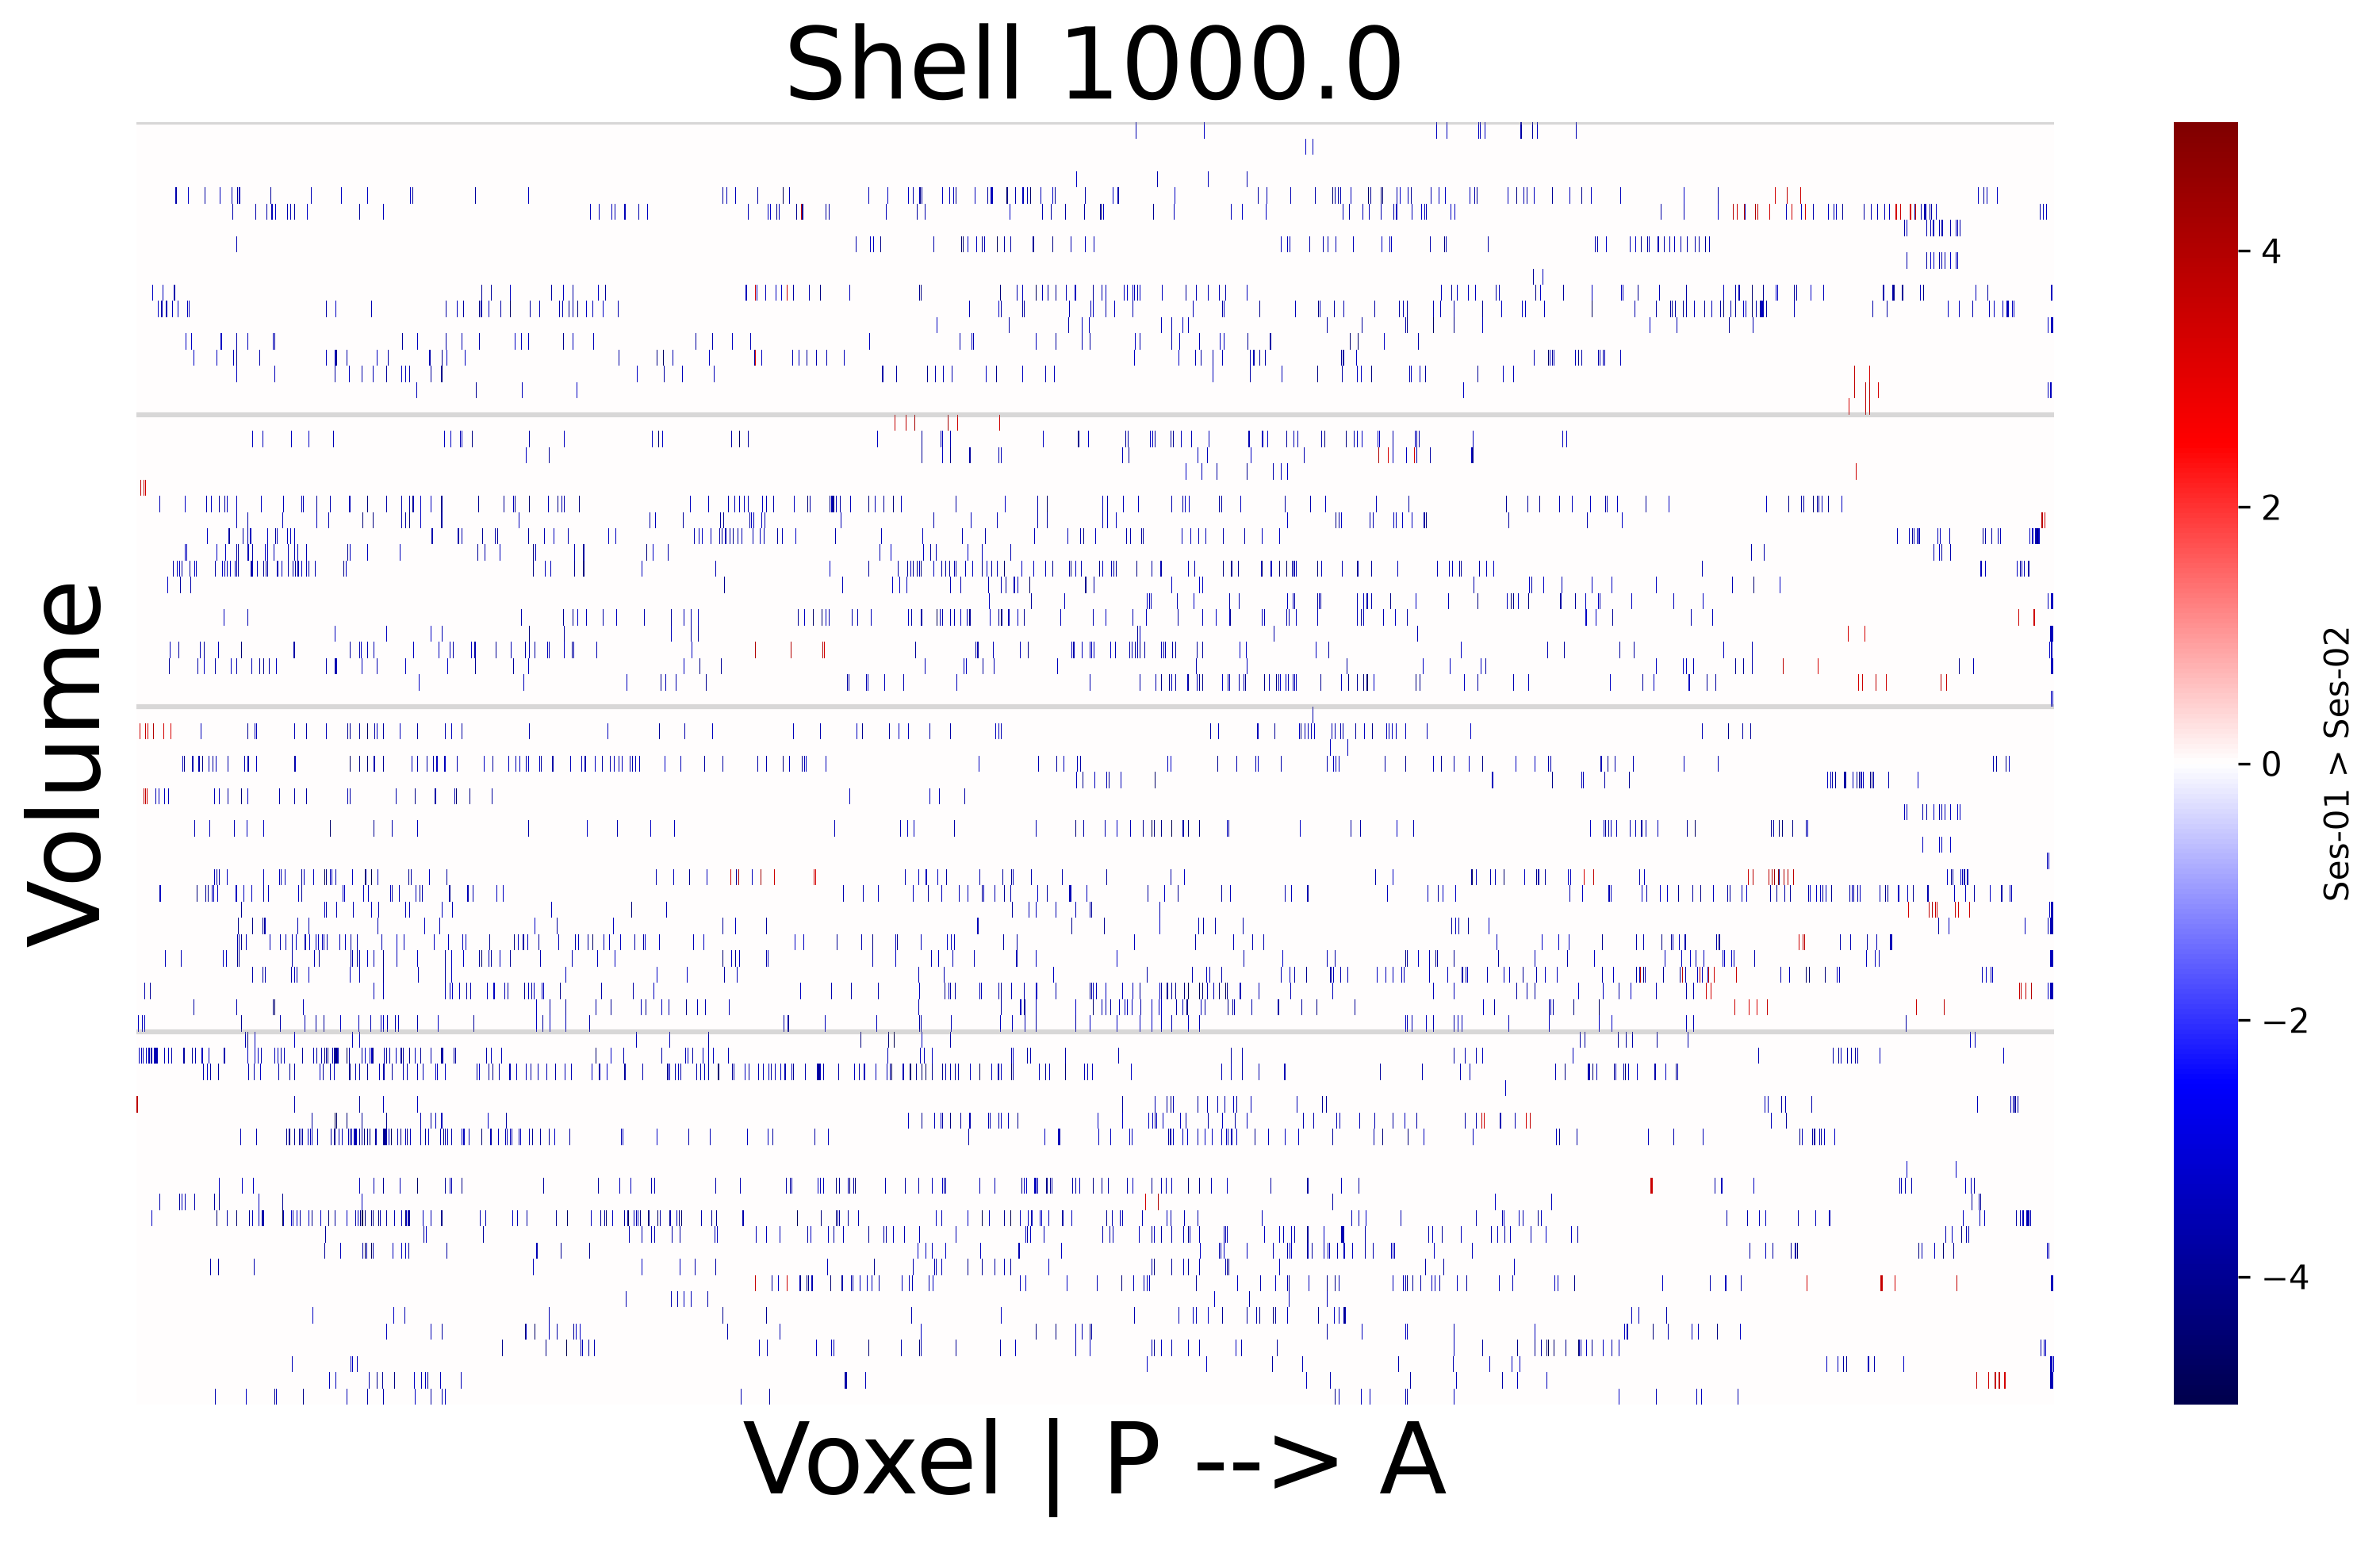

[INFO] shell=1500.0 THIRD_Oct AP=A vol47: entirely empty, skipping
[INFO] shell=1500.0 THIRD_Oct AP=A vol69: entirely empty, skipping
[INFO] shell=1500.0 THIRD_Oct AP=A vol86: entirely empty, skipping
[INFO] shell=1500.0 THIRD_Oct AP=B vol13: entirely empty, skipping
[INFO] shell=1500.0 FOURTH_Oct AP=A vol75: entirely empty, skipping
[INFO] shell=1500.0 FOURTH_Oct AP=B vol46: entirely empty, skipping
[INFO] shell=1500.0: orientation = ('L', 'A', 'S')


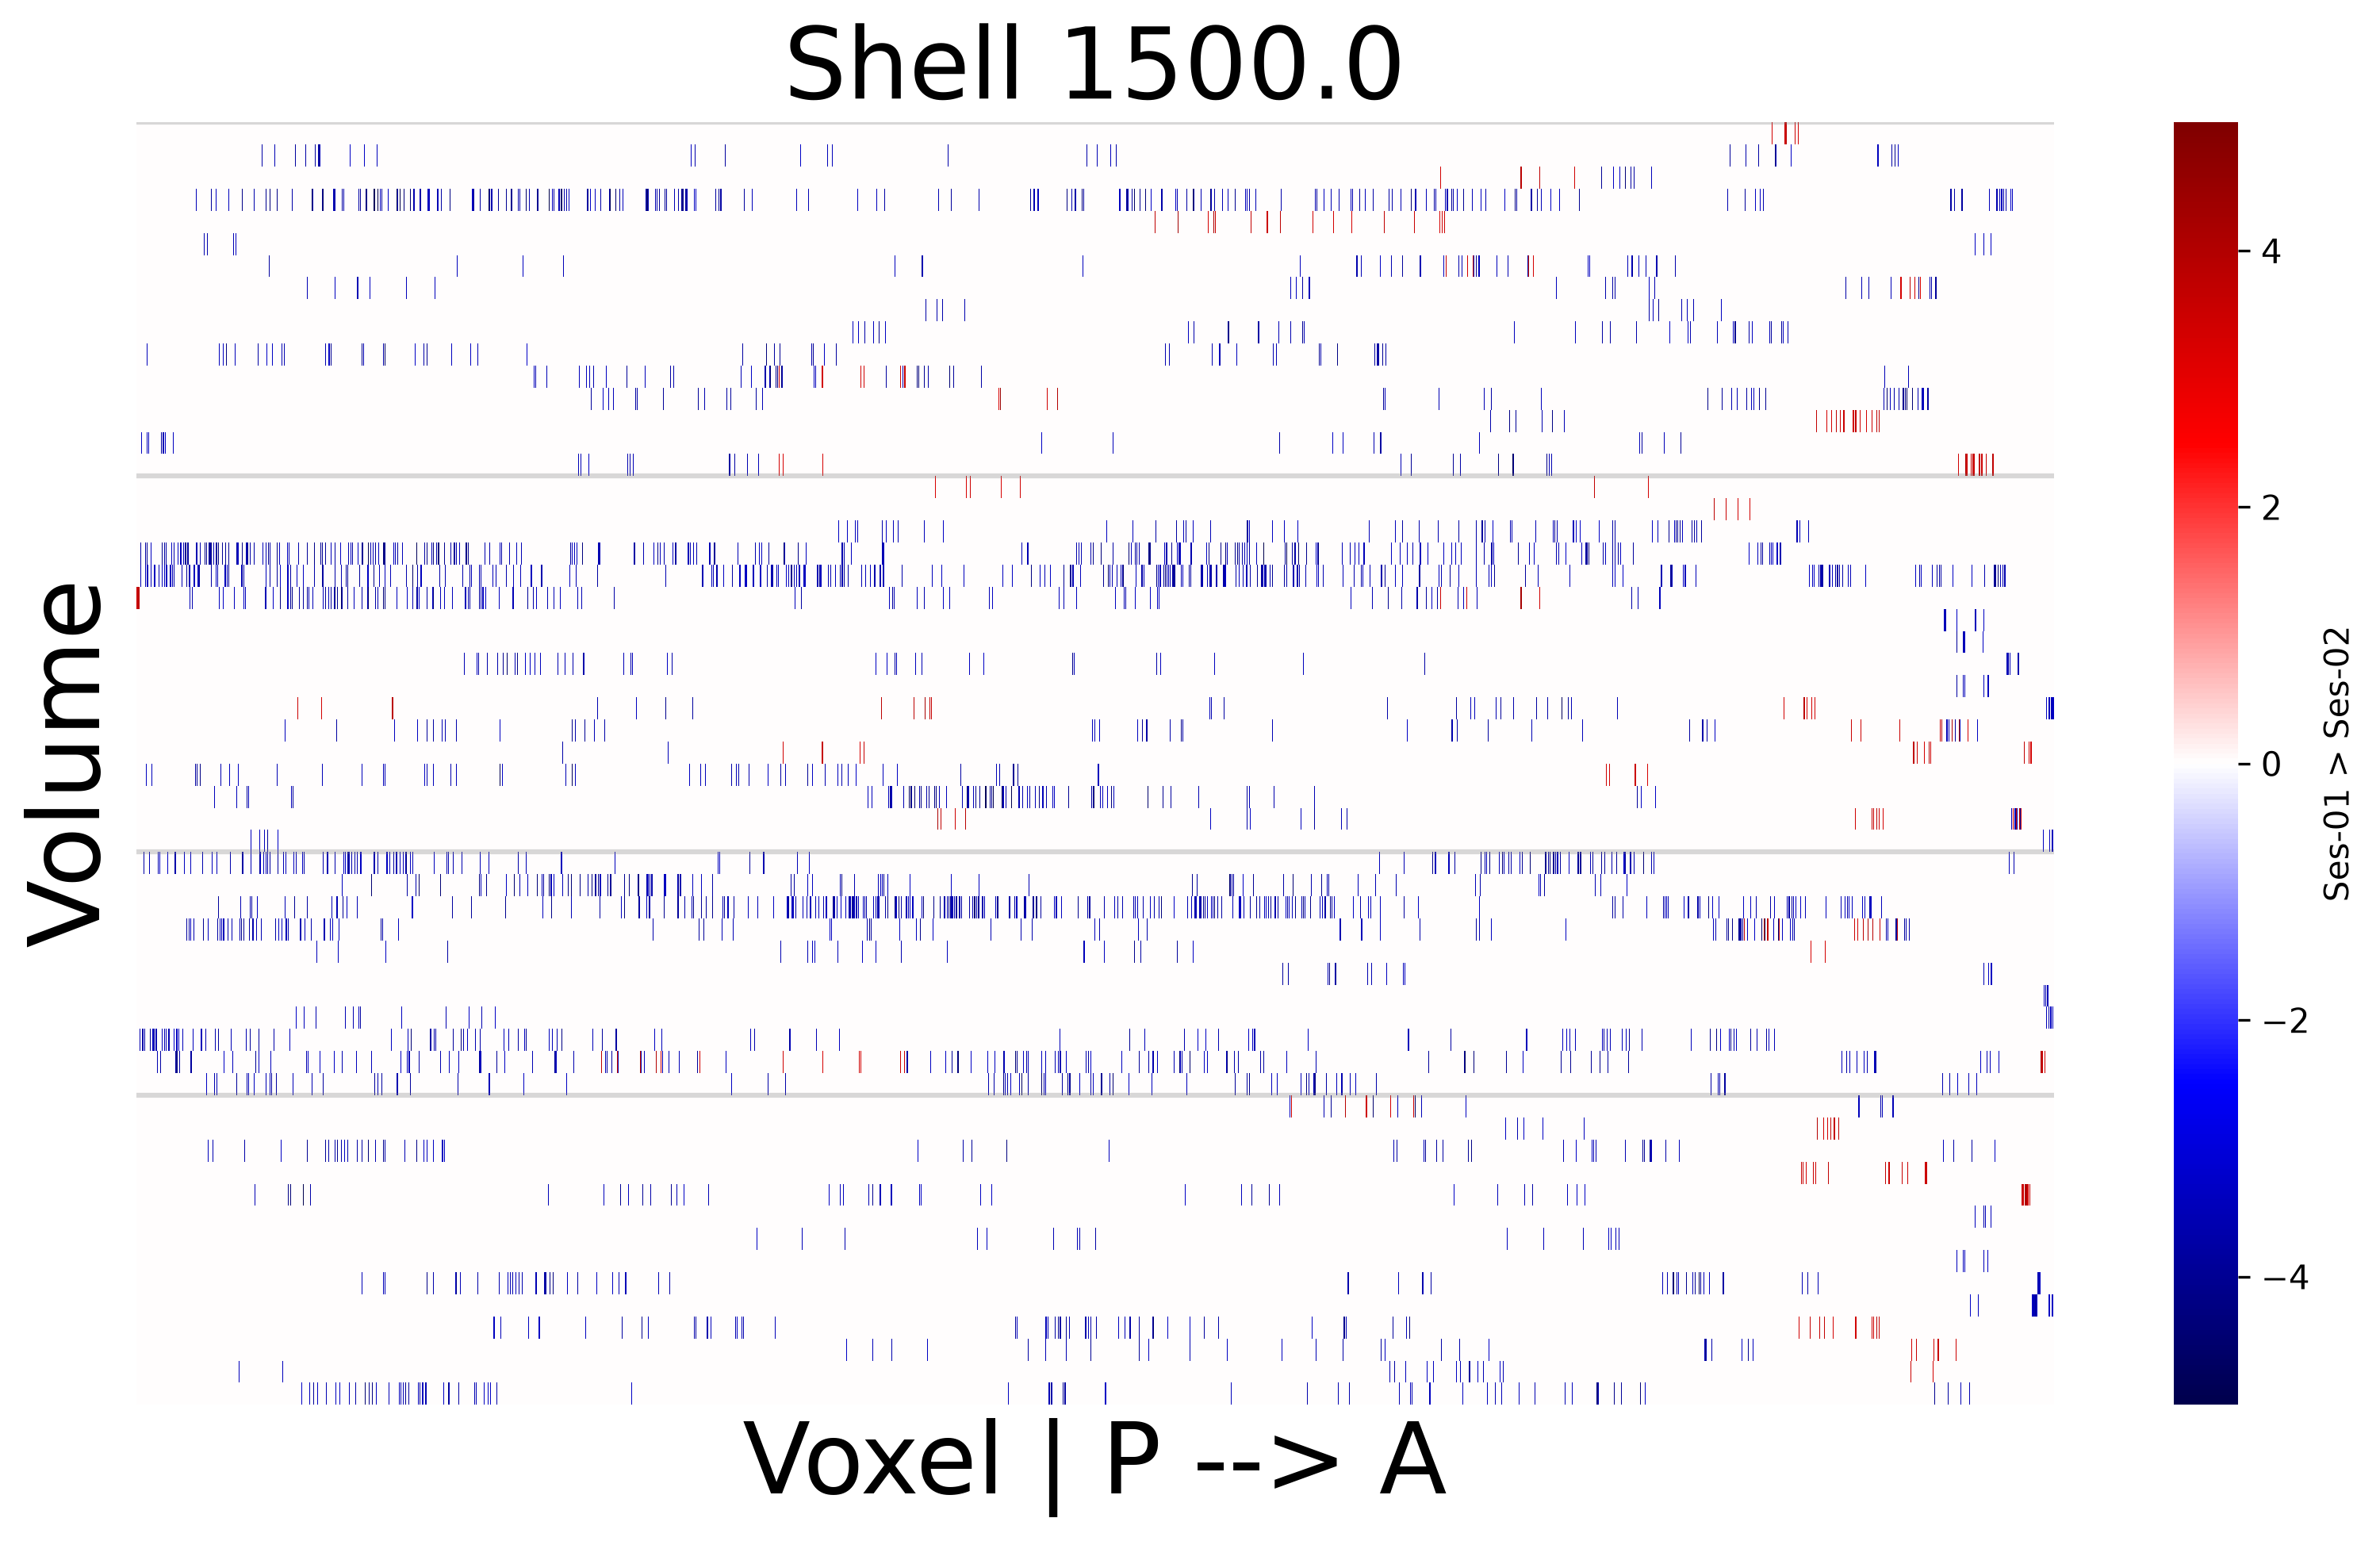

[INFO] shell=2000.0 FIRST_Oct AP=A vol48: entirely empty, skipping
[INFO] shell=2000.0 FIRST_Oct AP=A vol119: entirely empty, skipping
[INFO] shell=2000.0 FOURTH_Oct AP=C vol114: entirely empty, skipping
[INFO] shell=2000.0: orientation = ('L', 'A', 'S')


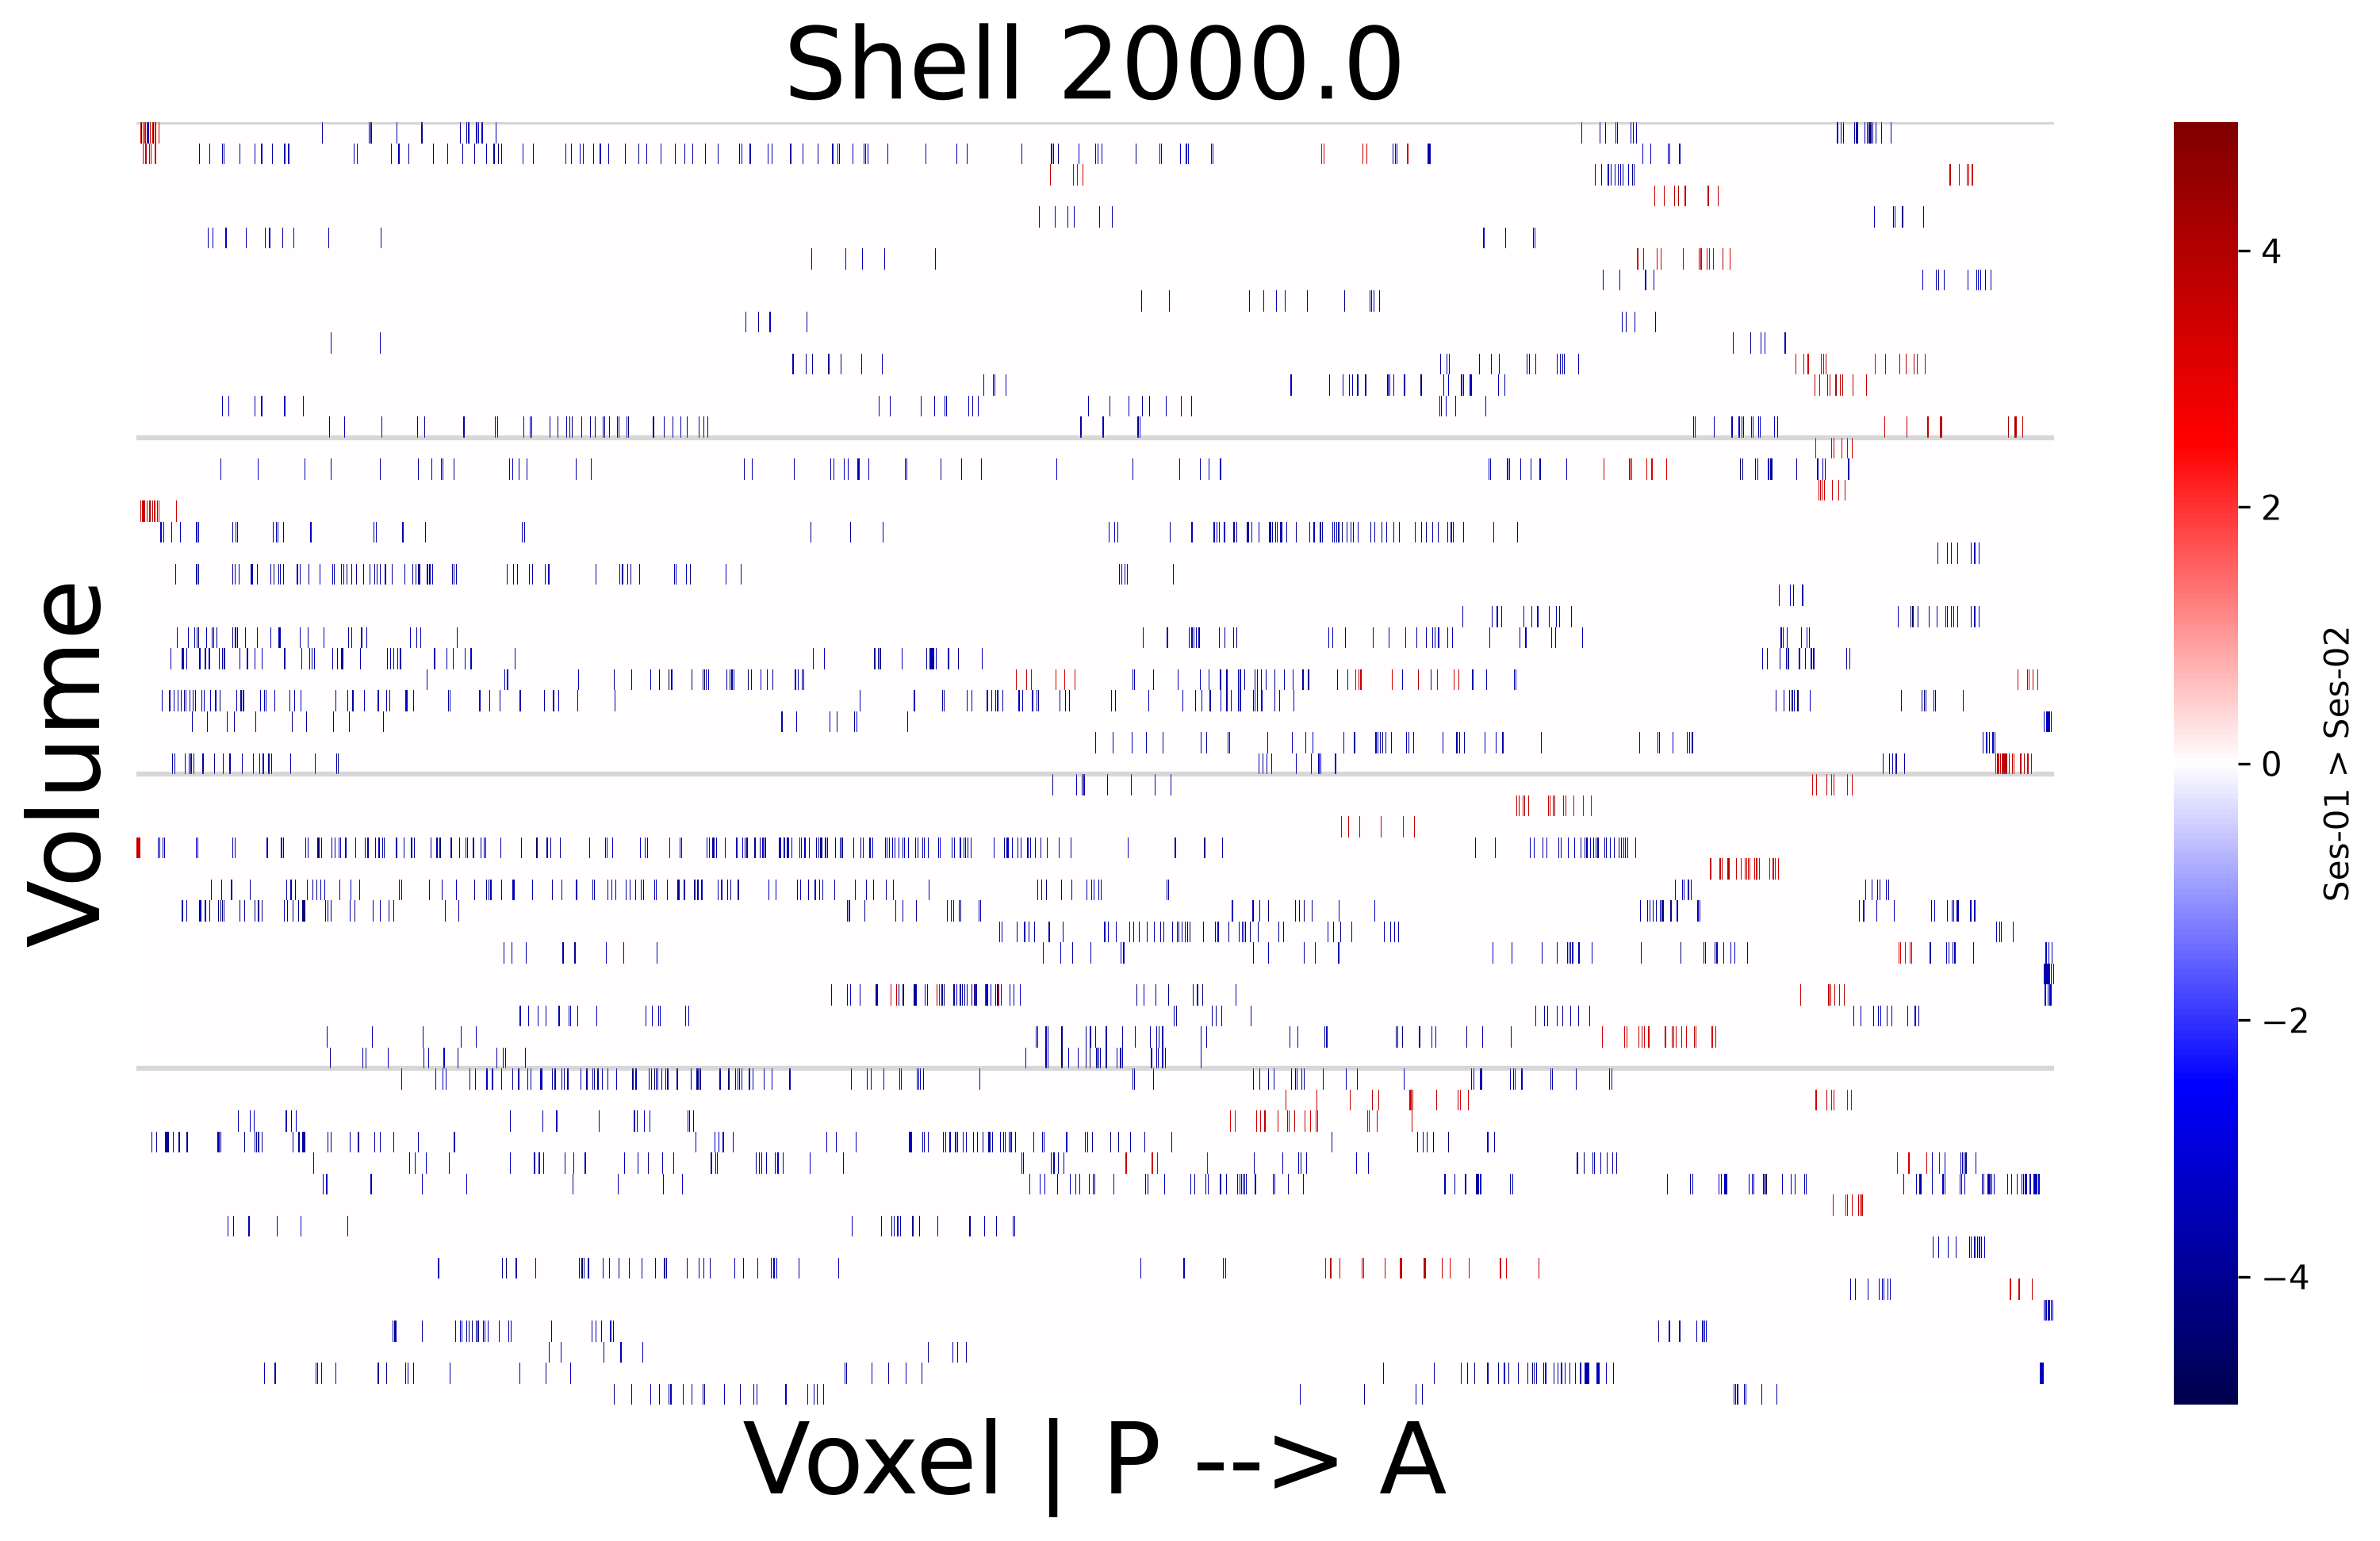

[INFO] shell=2800.0 FIRST_Oct AP=A vol5: entirely empty, skipping
[INFO] shell=2800.0 FIRST_Oct AP=A vol60: entirely empty, skipping
[INFO] shell=2800.0 FIRST_Oct AP=A vol99: entirely empty, skipping
[INFO] shell=2800.0 FIRST_Oct AP=A vol116: entirely empty, skipping
[INFO] shell=2800.0 SECOND_Oct AP=A vol27: entirely empty, skipping
[INFO] shell=2800.0 SECOND_Oct AP=A vol71: entirely empty, skipping
[INFO] shell=2800.0 SECOND_Oct AP=B vol118: entirely empty, skipping
[INFO] shell=2800.0 SECOND_Oct AP=C vol4: entirely empty, skipping
[INFO] shell=2800.0 THIRD_Oct AP=A vol49: entirely empty, skipping
[INFO] shell=2800.0 THIRD_Oct AP=B vol15: entirely empty, skipping
[INFO] shell=2800.0 FOURTH_Oct AP=A vol38: entirely empty, skipping
[INFO] shell=2800.0 FOURTH_Oct AP=A vol77: entirely empty, skipping
[INFO] shell=2800.0 FOURTH_Oct AP=A vol110: entirely empty, skipping
[INFO] shell=2800.0: orientation = ('L', 'A', 'S')


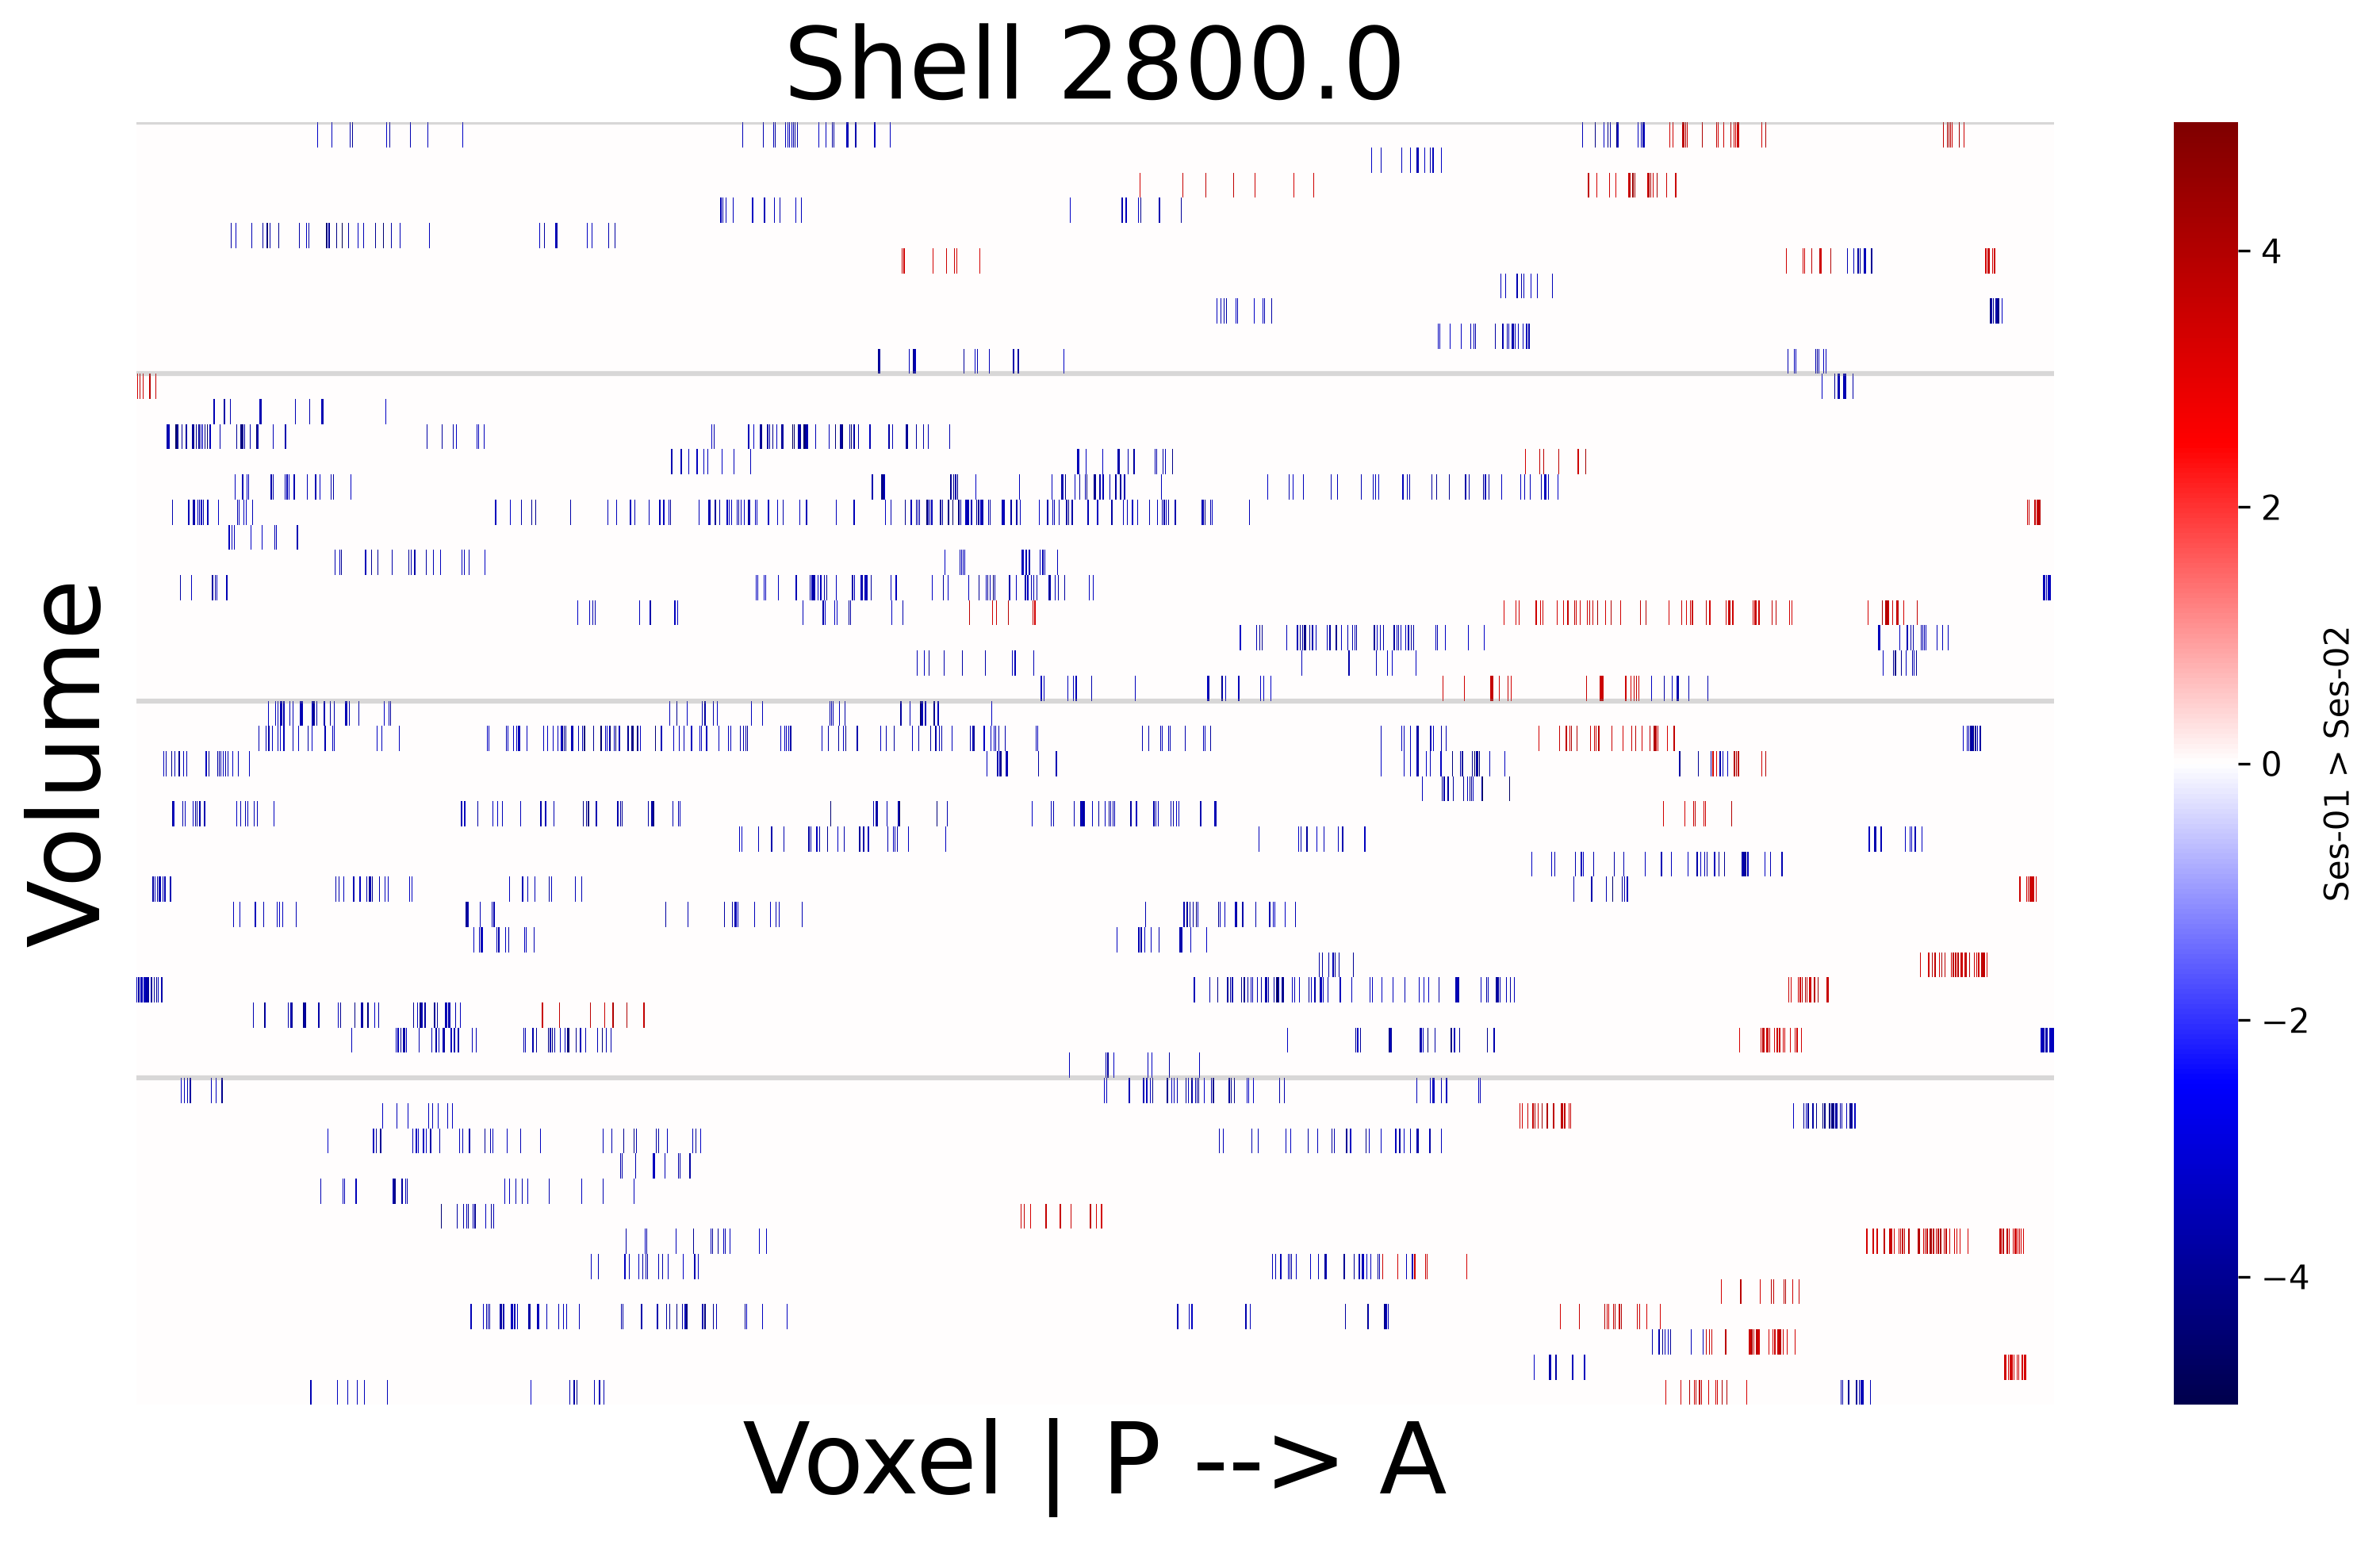

[INFO] Done


In [66]:
import os
import numpy as np
import nibabel as nib
from nibabel.affines import apply_affine
import matplotlib.pyplot as plt
import seaborn as sns

SMOOTH_FWHM_MM = "6"
ZTHRESH = 3.29
VLIM = 5  # fixed color scale: blue at -5, white/grey at 0, red at +5

home = r"/home/malberti/Unix_Folders/SWEEP2/derivatives"
out_dir = os.path.join("/home/malberti/Unix_Folders/SWEEP2", "Gradients_Stability_Analysis")
plot_dir = os.path.join(out_dir, "paired_ttest_plots")

for shell, quadrant in QUADRANT_indx.items():
    rows = []
    row_labels = []
    quadrant_boundaries = []
    quadrant_labels = []
    row_count = 0
    shape, affine = None, None

    for label, vol_index in quadrant.items():
        if len(vol_index) == 0:
            continue

        boundary_start = row_count

        for item in vol_index:
            AP = item[4]
            vol = int(item[5])

            zpath = os.path.join(out_dir, f"paired_ttest_zmap_{AP}_vol{vol}_smooth{SMOOTH_FWHM_MM}mm.nii.gz")
            img = nib.load(zpath)
            data = img.get_fdata()
            shape, affine = data.shape, img.affine  # same grid every volume
            #data[(data > -2) & (data < 2)] = 0
            row = np.ravel(data)

            if not np.any(row):
                print(f"[INFO] shell={shell} {label} AP={AP} vol{vol}: entirely empty, skipping")
                continue

            rows.append(row)
            row_labels.append(f"{label}_AP{AP}_vol{vol}")
            row_count += 1

        if row_count > boundary_start:  # only record boundary if this quadrant contributed rows
            quadrant_boundaries.append(boundary_start)
            quadrant_labels.append(label)

    if not rows:
        print(f"[WARN] shell={shell}: no non-empty volumes, skipping plot")
        continue

    axcodes = nib.aff2axcodes(affine)
    print(f"[INFO] shell={shell}: orientation = {axcodes}")

    matrix = np.vstack(rows)

    sig_cols = np.any(np.abs(matrix) > ZTHRESH, axis=0)
    original_voxel_indices = np.where(sig_cols)[0]
    matrix = matrix[:, sig_cols]

    voxel_ijk = np.array(np.unravel_index(original_voxel_indices, shape)).T
    voxel_mni = apply_affine(affine, voxel_ijk)
    y_coords = voxel_mni[:, 1]

    sort_order = np.argsort(y_coords)
    matrix = matrix[:, sort_order]
    y_sorted = y_coords[sort_order]

    fig, ax = plt.subplots(figsize=(13, 7), dpi=300)

    sns.heatmap(
    matrix,
    cmap="seismic", center=0, vmin=-VLIM, vmax=VLIM,
    cbar=True, cbar_kws={"label": "Ses-01 > Ses-02"},
    linecolor='black',
    xticklabels=False, yticklabels=False,
    ax=ax, robust=True, annot=False,
    square=False,
    )

    ax.set_title(f"Shell {shell}", fontsize=30)
    ax.set_xlabel("Voxel | P --> A",fontsize=30)
    ax.set_ylabel("Volume", fontsize=30)

# --- quadrant boundaries, drawn as faint grey lines ---
    for b, lbl in zip(quadrant_boundaries, quadrant_labels):
      ax.axhline(y=b, color="grey", linewidth=1.5, alpha=0.3)

    plt.show()

print("[INFO] Done")
